# 12 — Ablations finales

Cierre de la expansión del dataset y de la dimensión temporal. La pregunta es simple:
**de todo lo que se agregó, ¿qué aporta de verdad?**

Se ablacionan tres ejes contra el mismo modelo (XGBoost con los HP ya tuneados) y el mismo
protocolo (CV walk-forward de 4 folds, 3 semillas):

- **Memoria inter-campaña**: sin memoria / lags / momentum EWMA / ambos.
- **Suelo y geografía**: on / off.
- **Checkpoint**: los 5 momentos de la campaña.

La regla metodológica que ordena todo el notebook, y que se aprendió a los golpes en el
nb 11: **una feature estructural hay que medirla contra el modelo completo, no contra uno
sin memoria.** Medida en aislamiento, cualquier proxy del nivel del departamento parece
aportar; lo que importa es si aporta *además* de las features que ya están.

In [1]:
import os, sys, json, warnings, itertools
sys.path.insert(0, os.path.abspath(".."))     # componente_b/ (import plano)
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

import datos, evaluacion as ev, momentum as mom
from modelos.xgboost_model import XGBoostRegressor

CULTIVOS = ["soja", "maiz"]
SEEDS = [42, 52, 62]
HP = json.load(open("retuning_cv_honesta.json"))

# use_agro=False en toda la grilla: las ventanas críticas agronómicas llegan a marzo,
# así que solo existirían en 'full' y romperían la comparabilidad entre checkpoints.
FIJO = dict(enc_smooth=10.0)

MEMORIA = {
    "sin memoria":   dict(),
    "lags=3":        dict(use_lags=3),
    "momentum 0.7":  dict(use_momentum=0.7),
    "lags+momentum": dict(use_lags=3, use_momentum=0.7),
}

def cv(cultivo, **kw):
    p = dict(HP[cultivo]["xgb"]["best_params"])
    ds = datos.prepare(cultivo, **FIJO, **kw)
    r = np.mean([ev.cv_score(XGBoostRegressor, {**p, "random_state": s}, ds, n_splits=4)
                 for s in SEEDS])
    return r, len(ds.feature_cols)

print(f"grilla: {len(CULTIVOS)} cultivos x {len(datos.CHECKPOINTS)} checkpoints "
      f"x {len(MEMORIA)} memorias x 2 suelo = "
      f"{len(CULTIVOS)*len(datos.CHECKPOINTS)*len(MEMORIA)*2} configuraciones")

grilla: 2 cultivos x 5 checkpoints x 4 memorias x 2 suelo = 80 configuraciones


## 1 — La grilla completa

In [2]:
filas = []
for cultivo, ck, (mem_nom, mem_kw), suelo in itertools.product(
        CULTIVOS, datos.CHECKPOINTS, MEMORIA.items(), [False, True]):
    r, n = cv(cultivo, momento=ck, use_suelo=suelo, **mem_kw)
    filas.append({"cultivo": cultivo, "checkpoint": ck, "memoria": mem_nom,
                  "suelo": "con" if suelo else "sin", "feats": n, "CV-RMSE": r})
grid = pd.DataFrame(filas)
print(f"{len(grid)} configuraciones evaluadas")
grid.head()

[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
[data] clip rinde_kgha (0.5%/99.5% por cultivo): 98 filas afectadas


...

[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
[data] clip rinde_kgha (0.5%/99.5% por cultivo): 98 filas afectadas


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
[data] clip rinde_kgha (0.5%/99.5% por cultivo): 98 filas afectadas


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
[data] clip rinde_kgha (0.5%/99.5% por cultivo): 98 filas afectadas


80 configuraciones evaluadas


,cultivo,checkpoint,memoria,suelo,feats,CV-RMSE
0,soja,pre_siembra,sin memoria,sin,8,697.69
1,soja,pre_siembra,sin memoria,con,21,687.68
2,soja,pre_siembra,lags=3,sin,12,707.42
3,soja,pre_siembra,lags=3,con,25,704.16
4,soja,pre_siembra,momentum 0.7,sin,9,706.57


In [3]:
for cultivo in CULTIVOS:
    print(f"\n{'='*74}\n{cultivo.upper()} — CV-RMSE por checkpoint (filas) y configuración\n{'='*74}")
    piv = (grid[grid.cultivo == cultivo]
           .pivot_table(index="checkpoint", columns=["memoria", "suelo"], values="CV-RMSE")
           .reindex(list(datos.CHECKPOINTS)))
    piv = piv.reindex(columns=pd.MultiIndex.from_product([list(MEMORIA), ["sin", "con"]]))
    print(piv.round(1).to_string())


SOJA — CV-RMSE por checkpoint (filas) y configuración
            sin memoria        lags=3        momentum 0.7        lags+momentum       
                    sin    con    sin    con          sin    con           sin    con
checkpoint                                                                           
pre_siembra      697.70 687.70 707.40 704.20       706.60 690.70        708.70 702.50
nov              694.30 692.70 683.50 683.50       699.70 692.70        683.40 683.40
ene              646.20 645.50 637.70 640.70       647.10 645.10        638.30 639.90
pre_cosecha      631.60 629.00 624.10 624.60       633.80 630.20        624.80 624.80
full             625.70 623.30 618.50 618.00       626.40 622.70        618.70 617.80

MAIZ — CV-RMSE por checkpoint (filas) y configuración
            sin memoria            lags=3          momentum 0.7          lags+momentum         
                    sin      con      sin      con          sin      con           sin      con
checkpoint

## 2 — Efecto marginal de cada factor

Cuánto cambia el CV-RMSE al activar cada factor, **promediando sobre todas las demás
configuraciones**. Positivo = mejora (baja el error).

In [4]:
filas = []
for cultivo in CULTIVOS:
    g = grid[grid.cultivo == cultivo]

    # Suelo: comparado a igualdad de memoria y checkpoint.
    a = g[g.suelo == "sin"].set_index(["checkpoint", "memoria"])["CV-RMSE"]
    b = g[g.suelo == "con"].set_index(["checkpoint", "memoria"])["CV-RMSE"]
    d = (a - b) / a * 100
    filas.append({"cultivo": cultivo, "factor": "suelo/geo", "mejora % media": d.mean(),
                  "mejor caso": d.max(), "peor caso": d.min(),
                  "gana en": f"{int((d > 0).sum())}/{len(d)}"})

    # Memoria: cada variante contra 'sin memoria', a igualdad de checkpoint y suelo.
    base = g[g.memoria == "sin memoria"].set_index(["checkpoint", "suelo"])["CV-RMSE"]
    for nom in ["lags=3", "momentum 0.7", "lags+momentum"]:
        v = g[g.memoria == nom].set_index(["checkpoint", "suelo"])["CV-RMSE"]
        d = (base - v) / base * 100
        filas.append({"cultivo": cultivo, "factor": nom, "mejora % media": d.mean(),
                      "mejor caso": d.max(), "peor caso": d.min(),
                      "gana en": f"{int((d > 0).sum())}/{len(d)}"})
pd.DataFrame(filas).set_index(["cultivo", "factor"])

mejora % media  mejor caso  peor caso gana en
cultivo factor                                                      
soja    suelo/geo                0.40        2.24      -0.47   17/20
        lags=3                   0.50        1.55      -2.40    8/10
        momentum 0.7            -0.31        0.09      -1.27    2/10
        lags+momentum            0.50        1.56      -2.15    8/10
maiz    suelo/geo                1.69        5.50       0.71   20/20
        lags=3                   3.47        6.28      -4.15    8/10
        momentum 0.7             0.66        1.10      -0.74    9/10
        lags+momentum            3.61        6.13      -3.11    8/10

## 3 — ¿El momentum aporta sobre los lags?

El efecto marginal de arriba compara contra *sin memoria*, que es la comparación fácil. La
exigente es `lags+momentum` contra `lags=3` solo: ahí se ve si el EWMA agrega algo a lo que
el repo ya tenía. Se agrega el barrido de gamma que pedía el spec.

In [5]:
filas = []
for cultivo in CULTIVOS:
    for ck in datos.CHECKPOINTS:
        solo_lags, _ = cv(cultivo, momento=ck, use_suelo=True, use_lags=3)
        for g in mom.GAMMAS:
            r, _ = cv(cultivo, momento=ck, use_suelo=True, use_lags=3, use_momentum=g)
            filas.append({"cultivo": cultivo, "checkpoint": ck, "gamma": g,
                          "solo lags": solo_lags, "lags+momentum": r,
                          "mejora %": 100 * (solo_lags - r) / solo_lags})
gam = pd.DataFrame(filas)
resumen = (gam.groupby(["cultivo", "gamma"])["mejora %"]
           .agg(media="mean", mejor="max", peor="min",
                positivos=lambda s: f"{int((s > 0).sum())}/{len(s)}"))
resumen

[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
[data] clip rinde_kgha (0.5%/99.5% por cultivo): 98 filas afectadas


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
[data] clip rinde_kgha (0.5%/99.5% por cultivo): 98 filas afectadas


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
[data] clip rinde_kgha (0.5%/99.5% por cultivo): 98 filas afectadas


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


...

[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
[data] clip rinde_kgha (0.5%/99.5% por cultivo): 98 filas afectadas


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
[data] clip rinde_kgha (0.5%/99.5% por cultivo): 98 filas afectadas


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
[data] clip rinde_kgha (0.5%/99.5% por cultivo): 98 filas afectadas


media  mejor  peor positivos
cultivo gamma                              
maiz    0.50   -0.05   0.06 -0.18       2/5
        0.70    0.03   0.16 -0.10       3/5
        0.85    0.05   0.18 -0.09       4/5
soja    0.50    0.13   0.45 -0.03       4/5
        0.70    0.08   0.24 -0.03       4/5
        0.85   -0.13  -0.06 -0.21       0/5

## 4 — La mejor configuración de cada checkpoint

Para cada checkpoint se elige por CV (nunca por test) y recién ahí se reporta el test real
2021/22–2024/25.

In [6]:
filas = []
for cultivo in CULTIVOS:
    p = dict(HP[cultivo]["xgb"]["best_params"])
    g = grid[grid.cultivo == cultivo]
    for ck in datos.CHECKPOINTS:
        sub = g[g.checkpoint == ck].sort_values("CV-RMSE")
        mejor = sub.iloc[0]
        kw = dict(MEMORIA[mejor["memoria"]])
        kw["use_suelo"] = mejor["suelo"] == "con"
        ds = datos.prepare(cultivo, momento=ck, **FIJO, **kw)
        preds = [XGBoostRegressor(**{**p, "random_state": s})
                 .fit(ds.X_train, ds.y_train).predict(ds.X_test) for s in SEEDS]
        met = ev.metricas(ds.y_test, np.mean(preds, axis=0))
        base = ev.metricas(ds.y_test, ev.pred_media_depto(ds))
        filas.append({"cultivo": cultivo, "checkpoint": ck,
                      "config elegida": f"{mejor['memoria']} / suelo {mejor['suelo']}",
                      "CV-RMSE": mejor["CV-RMSE"], "test RMSE": met["rmse"],
                      "test R2": met["r2"],
                      "vs climatología %": 100 * (base["rmse"] - met["rmse"]) / base["rmse"]})
mejores = pd.DataFrame(filas).set_index(["cultivo", "checkpoint"])
mejores

[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
[data] clip rinde_kgha (0.5%/99.5% por cultivo): 98 filas afectadas


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
[data] clip rinde_kgha (0.5%/99.5% por cultivo): 98 filas afectadas


...

[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
[data] clip rinde_kgha (0.5%/99.5% por cultivo): 98 filas afectadas


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
[data] clip rinde_kgha (0.5%/99.5% por cultivo): 98 filas afectadas


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


config elegida  CV-RMSE  test RMSE  test R2  \
cultivo checkpoint                                                            
soja    pre_siembra    sin memoria / suelo con   687.68     730.22     0.09   
        nov          lags+momentum / suelo con   683.37     614.03     0.36   
        ene                 lags=3 / suelo sin   637.67     626.08     0.33   
        pre_cosecha         lags=3 / suelo sin   624.13     603.18     0.38   
        full         lags+momentum / suelo con   617.85     574.51     0.44   
maiz    pre_siembra   momentum 0.7 / suelo con 1,554.86   1,861.30     0.14   
        nov                 lags=3 / suelo con 1,489.65   1,695.81     0.29   
        ene          lags+momentum / suelo con 1,360.65   1,589.59     0.37   
        pre_cosecha  lags+momentum / suelo con 1,359.51   1,566.00     0.39   
        full                lags=3 / suelo con 1,365.87   1,558.58     0.40   

                     vs climatología %  
cultivo checkpoint                      
soja    pre_siembra              -3.09  
        nov                      13.32  
        ene                      11.62  
        pre_cosecha              14.85  
        full                     18.90  
maiz    pre_siembra              -4.26  
        nov                       5.01  
        ene                      10.96  
        pre_cosecha              12.28  
        full                     12.70

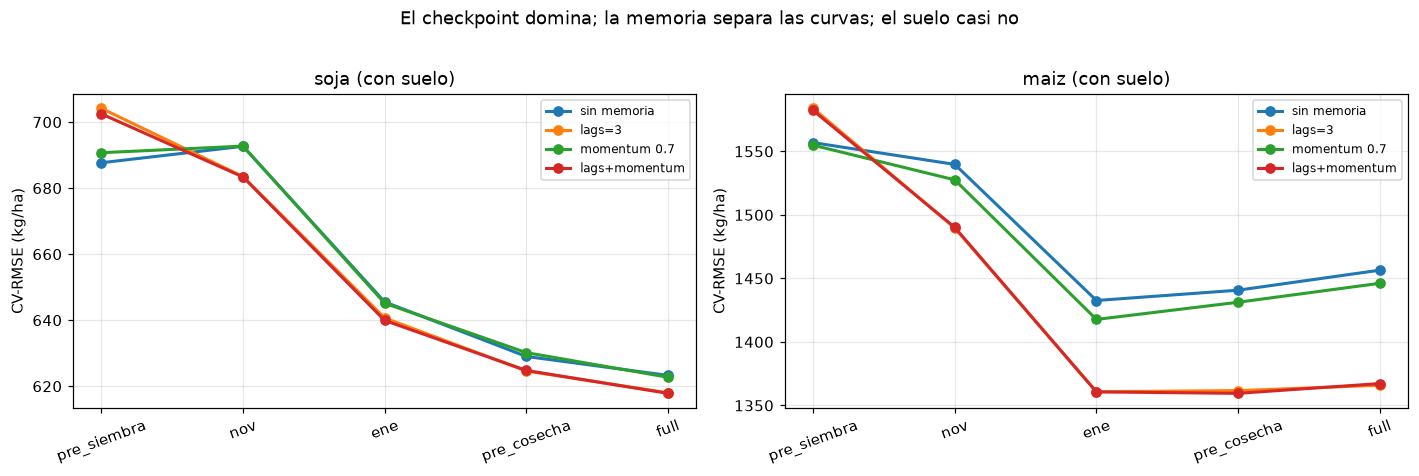

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, cultivo in zip(axes, CULTIVOS):
    g = grid[grid.cultivo == cultivo]
    for nom in MEMORIA:
        s = (g[(g.memoria == nom) & (g.suelo == "con")]
             .set_index("checkpoint")["CV-RMSE"].reindex(list(datos.CHECKPOINTS)))
        ax.plot(range(len(s)), s.values, "o-", lw=2, label=nom)
    ax.set_xticks(range(len(datos.CHECKPOINTS)))
    ax.set_xticklabels(list(datos.CHECKPOINTS), rotation=20)
    ax.set_ylabel("CV-RMSE (kg/ha)"); ax.set_title(f"{cultivo} (con suelo)")
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.suptitle("El checkpoint domina; la memoria separa las curvas; el suelo casi no", y=1.02)
plt.tight_layout(); plt.show()

## 5 — Cuánto pesa cada eje

Para poner los tres factores en la misma escala: cuánto CV-RMSE se gana moviendo cada uno
de su peor a su mejor valor, con los demás en su mejor configuración.

In [8]:
filas = []
for cultivo in CULTIVOS:
    g = grid[grid.cultivo == cultivo]
    mejor = g.loc[g["CV-RMSE"].idxmin()]
    # checkpoint: de pre_siembra a full, fijando la mejor memoria y suelo
    fijo = g[(g.memoria == mejor["memoria"]) & (g.suelo == mejor["suelo"])]
    rango_ck = fijo.set_index("checkpoint")["CV-RMSE"].reindex(list(datos.CHECKPOINTS))
    # memoria: en el mejor checkpoint y suelo
    fijo2 = g[(g.checkpoint == mejor["checkpoint"]) & (g.suelo == mejor["suelo"])]
    # suelo: en el mejor checkpoint y memoria
    fijo3 = g[(g.checkpoint == mejor["checkpoint"]) & (g.memoria == mejor["memoria"])]
    for eje, serie in [("checkpoint", rango_ck), ("memoria", fijo2.set_index("memoria")["CV-RMSE"]),
                       ("suelo/geo", fijo3.set_index("suelo")["CV-RMSE"])]:
        filas.append({"cultivo": cultivo, "eje": eje,
                      "peor": serie.max(), "mejor": serie.min(),
                      "rango kg/ha": serie.max() - serie.min(),
                      "rango %": 100 * (serie.max() - serie.min()) / serie.max()})
pd.DataFrame(filas).set_index(["cultivo", "eje"]).sort_values(["cultivo", "rango %"],
                                                              ascending=[True, False])

peor    mejor  rango kg/ha  rango %
cultivo eje                                               
maiz    checkpoint 1,582.18 1,359.51       222.67    14.07
        memoria    1,440.71 1,359.51        81.21     5.64
        suelo/geo  1,375.13 1,359.51        15.62     1.14
soja    checkpoint   702.47   617.85        84.62    12.05
        memoria      623.28   617.85         5.43     0.87
        suelo/geo    618.68   617.85         0.83     0.13

## 6 — ¿Desde cuándo el modelo sirve de verdad?

La tabla anterior deja algo incómodo: en pre-siembra la comparación contra la climatología
departamental da **negativa**. Vale la pena aislarlo, porque la selección por CV eligió para
ese checkpoint configuraciones distintas en cada cultivo y eso mezcla dos efectos.

Acá se fija una configuración razonable y única (`lags=3` + suelo) y se compara contra los
dos baselines de `evaluacion`: la media del departamento en train (climatología local, el
rival difícil) y la media global.

In [9]:
filas = []
for cultivo in CULTIVOS:
    p = dict(HP[cultivo]["xgb"]["best_params"])
    for ck in datos.CHECKPOINTS:
        ds = datos.prepare(cultivo, momento=ck, use_suelo=True, use_lags=3, **FIJO)
        preds = [XGBoostRegressor(**{**p, "random_state": s})
                 .fit(ds.X_train, ds.y_train).predict(ds.X_test) for s in SEEDS]
        m = ev.metricas(ds.y_test, np.mean(preds, axis=0))["rmse"]
        bd = ev.metricas(ds.y_test, ev.pred_media_depto(ds))["rmse"]
        bg = ev.metricas(ds.y_test, ev.pred_media(ds))["rmse"]
        filas.append({"cultivo": cultivo, "checkpoint": ck, "modelo": m,
                      "media depto": bd, "vs media depto %": 100 * (bd - m) / bd,
                      "vs media global %": 100 * (bg - m) / bg})
base = pd.DataFrame(filas).set_index(["cultivo", "checkpoint"])
base

[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


...

[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


modelo  media depto  vs media depto %  vs media global %
cultivo checkpoint                                                            
soja    pre_siembra   685.11       708.36              3.28              11.67
        nov           617.43       708.36             12.84              20.39
        ene           621.98       708.36             12.19              19.81
        pre_cosecha   597.13       708.36             15.70              23.01
        full          576.40       708.36             18.63              25.68
maiz    pre_siembra 1,819.01     1,785.23             -1.89              16.03
        nov         1,695.81     1,785.23              5.01              21.72
        ene         1,581.89     1,785.23             11.39              26.98
        pre_cosecha 1,566.41     1,785.23             12.26              27.69
        full        1,558.58     1,785.23             12.70              28.05

## Conclusión

**El orden de importancia es claro y el mismo en los dos cultivos: checkpoint ≫ memoria ≫
suelo.** Moviendo cada eje de su peor a su mejor valor: el checkpoint vale 12–14 % de
CV-RMSE, la memoria 0.9 % (soja) a 5.6 % (maíz), y el suelo 0.1 % a 1.1 %.

**1. El checkpoint domina, y era el objetivo del trabajo.** El modelo ahora se puede
consultar en cualquier momento de la campaña, con la precisión que corresponde a la
información disponible en ese momento.

**2. Pero no sirve desde el día cero.** En pre-siembra el modelo **no le gana a la
climatología departamental**: en maíz pierde (−1.9 % de RMSE contra predecir la media
histórica del departamento) y en soja apenas empata (+3.3 %). Recién desde noviembre la
ventaja se vuelve clara (+5 % a +13 %) y crece hasta +12.7 % (maíz) y +18.6 % (soja) con la
campaña completa. Contra la media global sí gana siempre, pero ése es el rival fácil.

> Lectura de producto: antes de sembrar, lo honesto es responder con la climatología del
> departamento. El modelo empieza a agregar valor **una vez que hay clima observado**. Es un
> límite del enfoque, no un bug: en pre-siembra las únicas señales son ONI, humedad de suelo
> invernal, el histórico del depto y el suelo — y eso no alcanza para anticipar una campaña.

**3. La memoria inter-campaña es el segundo factor, y ya estaba resuelta.** `use_lags=3`
—que el repo tenía desde antes— es lo que aporta: +3.5 % en maíz, +0.5 % en soja. El
momentum EWMA del spec no agrega nada útil encima: contra `lags=3` solo, las mejoras son de
±0.1 % y cambian de signo según el gamma y el checkpoint, o sea ruido. Solo, es peor que los
lags e incluso empeora el modelo en soja (−0.31 % promedio, gana en 2 de 10 casos).

**4. El suelo aporta poco, pero de forma consistente en maíz.** Promediando sobre todas las
configuraciones mejora 1.69 % en maíz —ganando en **20 de 20** comparaciones— y 0.40 % en
soja (17 de 20). El detalle importa: casi todo ese aporte está en pre-siembra y se diluye a
medida que entra el clima, y en soja, **una vez que están los lags, desaparece**.

**5. Lo que se aprendió sobre método.** Los dos resultados negativos de esta iteración
—momentum, y suelo en soja— salen del mismo error de medición: evaluar una feature
estructural contra un modelo sin memoria. Cualquier proxy del nivel del departamento luce
bien en aislamiento. **La comparación válida es contra el modelo completo**, y para el
juicio final, contra un baseline de climatología y no contra cero.